In [ ]:
import numpy as np

y = np.array([1, 2, 3])
np.random.uniform(0.001, y)

array([0.76689744, 1.54091178, 1.7895315 ])

In [4]:
from ler.lens_galaxy_population import OpticalDepth

ler = OpticalDepth()


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ./interpolator_json/axis_ratio/rayleigh_2.json
using ler available axis_rotation_angle function : uniform
using ler available d

In [ ]:
import numpy as np
size = 100
# check self.zs_sl.pdf is an instance and check self.zs_sl.rvs and self.zs_sl.function are callable and return finite outputs
zs = np.linspace(1.0, ler.z_max, size)
zl = np.random.uniform(0.001, zs)
ler.lens_redshift_sl.function(zl, zs)

array([7.29707234e-05, 3.15416457e-04, 5.45479503e-04, 4.95467176e-04,
       1.55838208e-05, 6.30023877e-05, 5.24397832e-04, 1.67084833e-04,
       1.24785039e-05, 6.75732699e-04, 1.60130367e-04, 8.13924693e-04,
       1.90926863e-05, 9.59372021e-04, 1.65415043e-05, 8.46781396e-04,
       1.09707883e-03, 4.59197915e-04, 6.71226106e-04, 1.19614496e-03,
       2.85897081e-04, 1.21433480e-04, 4.21538992e-08, 4.92832928e-04,
       5.50333815e-04, 6.75957661e-04, 1.24532687e-03, 3.89746121e-05,
       3.10163158e-04, 3.68305012e-04, 4.55603268e-06, 2.16586490e-05,
       9.74370396e-07, 1.34079525e-03, 1.24244120e-03, 6.76547819e-04,
       1.72284269e-04, 1.77446632e-05, 1.54662389e-05, 4.60790865e-04,
       7.90442517e-06, 1.69842193e-04, 1.72394471e-04, 5.37985805e-05,
       1.65989633e-03, 2.28768111e-04, 1.10021168e-03, 1.12371268e-04,
       4.07658852e-04, 1.73880536e-03, 8.88216447e-07, 2.26245084e-08,
       7.77992789e-04, 9.04764965e-05, 2.85194038e-05, 1.47926890e-06,
      

In [11]:
ler.lens_priors_params['velocity_dispersion']

{'param_name': 'velocity_dispersion',
 'sampler_type': 'velocity_dispersion_ewoud',
 'sigma_min': 100.0,
 'sigma_max': 400.0,
 'alpha': 0.94,
 'beta': 1.85,
 'phistar': np.float64(0.02099),
 'sigmastar': 113.78}

In [1]:
from ler import GWRATES
gwrates_instance = GWRATES()


Initializing GWRATES class...


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_2.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_3.json
merger_rate_density_based_source_redshift interpolator will be loaded from ./interpolator_json/merger_rate_density_based_source_redshift/merger_rate_density_bas

In [9]:
# trim_to_size=False: accumulate until >= size detectable events are found
rate, param = gwrates_instance.selecting_n_gw_detectable_events(
    size=500, 
    batch_size=10000, 
    stopping_criteria=None,
    pdet_threshold=0.5, 
    resume=True, 
    trim_to_size=True,
    output_jsonfile="unit_n_detectable.json",
    meta_data_file="unit_meta_gw.json",
)

stopping criteria not set. sample collection will stop when number of detectable events exceeds the specified size.
Resuming from 510 detectable events.
Given size=500 reached

Stopping criteria met. There will be no more samples collected.
collected number of detectable events =  510
stored detectable GW params in ./ler_data/unit_n_detectable.json
stored meta data in ./ler_data/unit_meta_gw.json

 trimming final result to size=500
collected number of detectable events =  500
total number of events =  137255.0
total GW event rate (yr^-1): 333.6264698228916


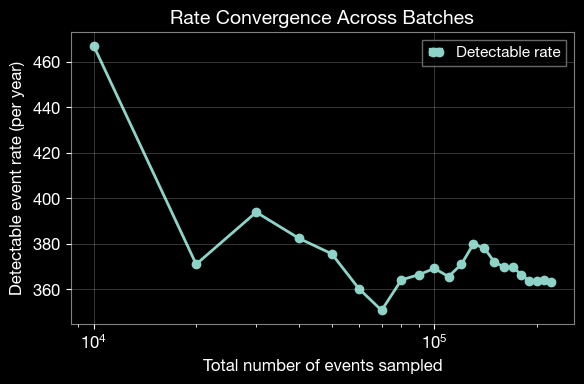

In [6]:
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json

# Load metadata containing rates for each batch
meta_data = get_param_from_json(gwrates_instance.ler_directory + '/unit_meta_gw.json')

# Plot rate vs sampling size
plt.figure(figsize=(6, 4))
plt.plot(
    meta_data['events_total'],
    meta_data['total_rate'],
    'o-',
    linewidth=2,
    markersize=6,
    label='Detectable rate'
)

plt.xlabel('Total number of events sampled', fontsize=12)
plt.ylabel('Detectable event rate (per year)', fontsize=12)
plt.title('Rate Convergence Across Batches', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.xscale('log')
plt.tight_layout()
plt.show()

In [ ]:
LeR(
                npool=NPOOL,
                z_min=Z_MIN,
                z_max=Z_MAX,
                event_type="BBH",
                lens_type="sie_galaxy",
                interpolator_directory=interpolator_directory,
                ler_directory=sub,
                create_new_interpolator=False,
                lens_priors_params={
                    "velocity_dispersion": velocity_dispersion_prior(phistar),
                },
            )

In [1]:
8.0e-3 * 0.7**3

0.0027439999999999995

In [1]:
from ler import GWRATES, LeR
from astropy.cosmology import LambdaCDM
ler = LeR(
    event_type="BBH", 
    lens_type="sie_galaxy",
    lens_priors_params={
        "velocity_dispersion": dict(sigma_min=100.0, sigma_max=400.0, alpha=0.94, beta=1.85, phistar=0.0027439999999999995, sigmastar=113.78),
    },
    # ifos=['ET','CE'], 
    # snr_method="interpolation_no_spins",
    # cosmology=LambdaCDM(
    #     H0=67.66+0.42, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0
    # ),
    # gw_functions_params=dict(merger_rate_density=dict(R0=26.0*1e-9)),
    # gw_priors_params=dict(mass_1_source=dict(alpha_1=2.86)),
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_8.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ./interpolator_json/axis_ratio/rayleigh_8.j

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# size = 1000
# zs = np.linspace(0.01, ler.z_max, size)
# # zs_sl_low = ler.zs_sl.pdf(zs)
# zs_sl_high = ler.zs_sl.pdf(zs)

# plt.plot(zs, zs_sl_low, label='low')
# plt.plot(zs, zs_sl_high, label='high')
# # plt.yscale('log')
# # plt.xscale('log')
# plt.legend()
# plt.show()

In [24]:
# import numpy as np
# import matplotlib.pyplot as plt

# size = 1000
# zs = np.linspace(0.01, ler.z_max, size)
# # tau_low = ler.optical_depth(zs)
# # tau_high = ler.optical_depth(zs)

# plt.plot(zs, tau_low, label='low')
# plt.plot(zs, tau_high, label='high')
# # plt.yscale('log')
# # plt.xscale('log')
# plt.legend()
# plt.show()


In [2]:
lensd_param = ler.lensed_cbc_statistics(size=50000, batch_size=50000, resume=False);

lensed params will be stored in ./ler_data/lensed_param.json
removing ./ler_data/lensed_param.json if it exists
Batch no. 1
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 3182 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 219 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 20 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 3 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image pro

In [3]:
lensed_rate, _ = ler.lensed_rate(lensd_param)

Using provided lensed_param dict...
total lensed rate (yr^-1): 0.014658317465650834
number of simulated lensed detectable events: 56
number of simulated all lensed events: 50000
storing detectable params in ./ler_data/lensed_param_detectable.json


In [19]:
ler.normalization_pdf_z_lensed

95.44791721728915

- phistar high (higher optical depth)
  - ler.normalization_pdf_z_lensed=104.85583416987373
  - total lensed rate (yr^-1): 0.10485583416987374
- low
  - ler.normalization_pdf_z_lensed=95.44791721728915
  - total lensed rate (yr^-1): 0.11930989652161143
  - number of simulated lensed detectable events: 25
  - number of simulated all lensed events: 20000

In [49]:
unlensd_param = ler.gw_cbc_statistics(size=100000, batch_size=100000, resume=False);

Simulated GW params will be stored in ./ler_data/gw_param.json
removing ./ler_data/gw_param.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
saving all gw parameters in ./ler_data/gw_param.json 


In [50]:
ler.gw_rate();

Getting gw parameters from json file ./ler_data/gw_param.json...
total GW event rate (yr^-1): 238.1178858008131
number of simulated GW detectable events: 260
number of simulated all GW events: 100000
storing detectable params in ./ler_data/gw_param_detectable.json


In [52]:
# import matplotlib.pyplot as plt
# plt.hist(unlensd_param['mass_1_source'], bins=100, density=True)
# plt.yscale('log')
# plt.ylim(1e-3, 4e-1)
# plt.xlim(5, 90)
# plt.show()

In [53]:
ler.normalization_pdf_z

91583.80223108197

- H0_LOW = 67.66-0.42
    - ler.normalization_pdf_z: 103330.76933381737
    - total GW event rate (yr^-1): 347.1913849616264
- H0_HIGH =  67.66+0.42
    - ler.normalization_pdf_z: 99552.95049869675
    - total GW event rate (yr^-1): 334.4979136756211

- R0_LOW = 14
    - ler.normalization_pdf_z: 67482.79965812019
    - total GW event rate (yr^-1): 259.80877868376274
- R0_HIGH = 
    - ler.normalization_pdf_z: 125325.19936508035
    - total GW event rate (yr^-1): 434.8784417968288

- ALPHA_1_LOW = -0.05
    - total GW event rate (yr^-1): 690.541868822358
- ALPHA_1_LOW = 2.86
    - total GW event rate (yr^-1): 238.1178858008131

In [74]:
size = 2
np.array([0,1]).shape==(size,)

True

In [6]:
# trim_to_size=False: accumulate until >= size detectable events are found
rate, param = ler.selecting_n_lensed_detectable_events(
    size=50, 
    batch_size=10000, 
    stopping_criteria=None,
    pdet_threshold=0.5, 
    resume=False,
)

stopping criteria not set. sample collection will stop when number of detectable events exceeds the specified size.
removing ./ler_data/n_lensed_params_detectable.json if it exists
removing ./ler_data/meta_lensed.json if it exists
collected number of detectable events =  0
collected number of detectable events (batch) =  0
collected number of detectable events (cumulative) =  0
total number of events =  10000
total rate (yr^-1): 0.0
collected number of detectable events (batch) =  0
collected number of detectable events (cumulative) =  0
total number of events =  20000
total rate (yr^-1): 0.0
collected number of detectable events (batch) =  0
collected number of detectable events (cumulative) =  0
total number of events =  30000
total rate (yr^-1): 0.0
collected number of detectable events (batch) =  0
collected number of detectable events (cumulative) =  0
total number of events =  40000
total rate (yr^-1): 0.0
collected number of detectable events (batch) =  0
collected number of det

RuntimeError: Error in epl_solver. Try running it again; raise a github issue if the problem persists. Debug values saved to debug_epl_solver.npz